In [1]:
import argparse
import sys
import os
from pathlib import Path

import h5py
import numpy as np
from scipy.stats import qmc

sys.path.insert(0, "TelFit/src")
from telfit import Modeler
modeler = Modeler()

/home/ubuntu/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/ubuntu/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/home/ubuntu/miniconda3/envs/tellurics/lib/python3.10/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# === Configuration ===
PARAM_RANGES = {
    "pressure": (750, 850),  # hPa
    "temperature": (270, 300),  # Kelvin
    "angle": (5, 60),  # zenith distance (degrees)
    "humidity": (10, 90),  # percent
    "co2": (350, 450),  # ppmv
    "o3": (0.02, 0.08),  # ppmv
    "n2o": (0.30, 0.35),  # ppmv
    "co": (0.05, 0.30),  # ppmv
    "ch4": (1.7, 2.1),  # ppmv
    "o2": (209000, 210000),  # ppmv
    "no": (1e-5, 1e-3),  # ppmv
    "so2": (1e-5, 1e-3),  # ppmv
    "no2": (1e-5, 1e-3),  # ppmv
    "nh3": (1e-5, 1e-3),  # ppmv
    "hno3": (1e-4, 1e-3),  # ppmv
}

FIXED_PARAMS = {
    "lat": 30.6,
    "alt": 2.1,
}

WAVESTART_NM = 500.0
WAVEEND_NM = 1800.0

STELLAR_H5 = Path("/home/ubuntu/Tellurics/Phoenix/phoenix_spectra.h5")
OUTDIR = Path("/home/ubuntu/Tellurics/TelFit/telluric_templates")
CHUNKS_DIR = OUTDIR / "chunks"

param_names = list(PARAM_RANGES.keys())
bounds_low = [v[0] for v in PARAM_RANGES.values()]
bounds_high = [v[1] for v in PARAM_RANGES.values()]


samples_unit = qmc.LatinHypercube(d=len(param_names), seed=42).random(n=10)
samples = qmc.scale(samples_unit, bounds_low, bounds_high)
params = dict(zip(param_names, samples))


In [3]:
params_one = dict(zip(param_names, np.round(samples[0], 2).astype(float)))  # Use the first sample for testing
params_one_ = dict(zip(param_names, samples[0]))  # Use the first sample for testing

In [25]:
def get_stellar_wavegrid():
    """Load the stellar wavelength grid (in um)."""
    with h5py.File(STELLAR_H5, "r") as hf:
        return hf["wavelengths"]  # (D,) in um

    # with h5py.File(STELLAR_H5, "r") as hf:
    #     print(list(hf.keys()))
    #     print(hf["wavelengths"][:].shape)
    #     print(hf["flux"][:].shape)
    #     print(hf["labels"][:].shape)
    #     print(hf["labels"].attrs["columns"])

    # return hf["wavelengths"][:].astype(np.float32)  # (D,) in um


# Load stellar wavegrid
stellar_wavegrid_um = get_stellar_wavegrid()
wavegrid_nm = stellar_wavegrid_um * 1000  # um -> nm

print(wavegrid_nm.shape, " see this first")
print(stellar_wavegrid_um)

TypeError: unsupported operand type(s) for *: 'Dataset' and 'int'

In [5]:
# model = modeler.MakeModel(
#                 lowfreq=1e7 / WAVEEND_NM,
#                 highfreq=1e7 / WAVESTART_NM,
#                 wavegrid=wavegrid_nm,
#                 **params_one,
#                 **FIXED_PARAMS,
#             )

In [9]:
params_one, params_one_

({'pressure': 832.26,
  'temperature': 280.68,
  'angle': 5.78,
  'humidity': 28.42,
  'co2': 379.06,
  'o3': 0.04,
  'n2o': 0.3,
  'co': 0.23,
  'ch4': 1.93,
  'o2': 209354.96,
  'no': 0.0,
  'so2': 0.0,
  'no2': 0.0,
  'nh3': 0.0,
  'hno3': 0.0},
 {'pressure': 832.2604395144403,
  'temperature': 280.68336468074386,
  'angle': 5.777711440487397,
  'humidity': 28.42105576752509,
  'co2': 379.0582265211235,
  'o3': 0.03814626589017947,
  'n2o': 0.3011943014900482,
  'co': 0.23034839236807614,
  'ch4': 1.9348754546929783,
  'o2': 209354.96140621044,
  'no': 0.0005672909956009745,
  'so2': 0.0007102502661039885,
  'no2': 0.0008372573531120141,
  'nh3': 2.7546600286187833e-05,
  'hno3': 0.0005100927221055403})


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
6.65user 1.47system 0:08.12elapsed 99%CPU (0avgtext+0avgdata 7732maxresident)k
0inputs+1884104outputs (0major+1097minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
3.38user 1.15system 0:04.54elapsed 100%CPU (0avgtext+0avgdata 7760maxresident)k
0inputs+1507408outputs (0major+1099minor)pagefaults 0swaps



Running exec: lblrtm




...


Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
0.72user 0.74system 0:01.46elapsed 100%CPU (0avgtext+0avgdata 7728maxresident)k
0inputs+682320outputs (0major+1087minor)pagefaults 0swaps



Running exec: lblrtm




Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL
STOP  LBLRTM EXIT 
0.28user 0.46system 0:00.75elapsed 99%CPU (0avgtext+0avgdata 7548maxresident)k
0inputs+129904outputs (0major+1076minor)pagefaults 0swaps


OK: 5993700 points


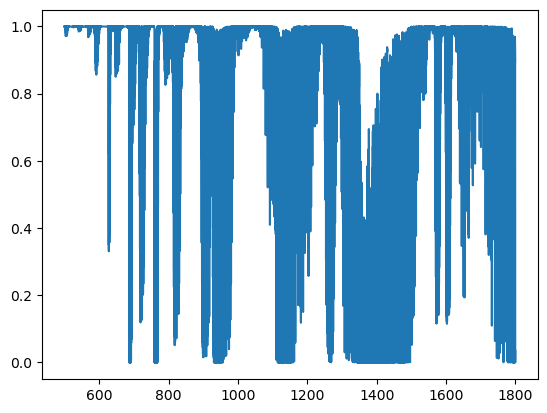

In [14]:
m = Modeler()
model = m.MakeModel(lowfreq=1e7/1800, highfreq=1e7/500, \
                    wavegrid=wavegrid_nm, **FIXED_PARAMS, **params_one)
print(f'OK: {len(model.x)} points')

from matplotlib import pyplot as plt

plt.plot(model.x, model.y)
plt.show()

In [21]:
import inspect

# print(inspect.signature(Modeler.MakeModel))
wavegrid_nm

array([], shape=(26200, 0), dtype=float32)

In [12]:
model = m.MakeModel(lowfreq=1e7/1800, highfreq=1e7/500, \
                    wavegrid=wavegrid_nm, **FIXED_PARAMS, **params_one_)
print(f'OK: {len(model.x)} points')

plt.plot(model.x, model.y)
plt.show()


Running exec: lblrtm





Program received signal SIGSEGV: Segmentation fault - invalid memory reference.

Backtrace for this error:
#0  0x7c6386023e59 in ???
#1  0x7c6386022e75 in ???
#2  0x7c6385c4532f in ???
#3  0x5c811e0589fb in convf4_
#4  0x5c811e04d1eb in lblf4_
#5  0x5c811e060af4 in hirac1_
#6  0x5c811e02e146 in opdpth_
#7  0x5c811e029b2b in xlayer_
#8  0x5c811e0461e1 in MAIN__
#9  0x5c811e046cfd in main
Command terminated by signal 11
2.88user 0.70system 0:04.68elapsed 76%CPU (0avgtext+0avgdata 7708maxresident)k
0inputs+844880outputs (0major+1179minor)pagefaults 0swaps


TypeError: CalledProcessError.__init__() missing 1 required positional argument: 'cmd'

(self, pressure=795.0, temperature=283.0, lowfreq=4000, highfreq=4600, angle=45.0, humidity=50.0, co2=368.5, o3=0.039, n2o=0.32, co=0.14, ch4=1.8, o2=210000.0, no=1.1e-19, so2=0.0001, no2=0.0001, nh3=0.0001, hno3=0.00056, lat=30.6, alt=2.1, wavegrid=None, resolution=None, save=False, libfile=None, vac2air=True)
